# OceanScan - Prediction

Runs the trained YOLOv8n model (`best.pt`) on test images.

Pipeline per image:
1. **Noise filtering** (same function from `noise_filtering.ipynb`)
2. **Prediction** via YOLOv8n
3. **Show boxes ONLY if a detection is found** (confidence above threshold); otherwise show the image with no boxes

Test sources:
- `input/image/` (user image predictions)
- `dataset2/text/images` (dataset2 test set -> `output/test_predictions/`)

## 0. Dependencies

"Run All" auto-installs anything that is missing (e.g. `cv2`), so no manual `pip install` is needed.

## 1. Setup

In [5]:
import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

ROOT = Path(r"D:\1. Project Program\1.SIH\SonarVision")
BEST = ROOT / "backend" / "best.pt"
HOME = Path.home()

CLASS_NAMES = {0: "human", 1: "pipe", 2: "shipwreck", 3: "crabpot", 4: "cylinder", 5: "plane"}
CONF_THRESHOLD = 0.25  # only draw boxes above this confidence

In [6]:
def load_noise_filter_from_nb(nb_path: Path):
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    ns = {"__name__": "noise_filtering_mod", "cv2": cv2, "np": np, "Path": Path}
    for cell in nb["cells"]:
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if "def filter_noise" in source or "def preprocess_for_model" in source:
            exec(source, ns)
    return ns


NF_NB = ROOT / "backend" / "noise_filtering.ipynb"
if not NF_NB.exists():
    NF_NB = ROOT / "noise_filtering.ipynb"
fns = load_noise_filter_from_nb(NF_NB)
preprocess = fns["preprocess_for_model"]

if not BEST.exists():
    print(f"WARNING: model not found at {BEST} - run model.ipynb first.")
model = None
if BEST.exists():
    model = YOLO(str(BEST))
    print("Model loaded:", BEST)

Model loaded: D:\1. Project Program\1.SIH\SonarVision\backend\best.pt


## 2. Run prediction

Set `SOURCE_DIRS` to the folders you want to test. Default: `input/image/` (image predictions).
The companion section below runs the **dataset2** test set (`dataset2/text/images`) and saves results to `output/test_predictions/`.

> If `best.pt` is missing, set `model = None` above and only the "save predictions" section will still copy noise-filtered images.


=== D:\1. Project Program\1.SIH\SonarVision\input\image (7 images) ===
  !! cannot read: .ipynb_checkpoints


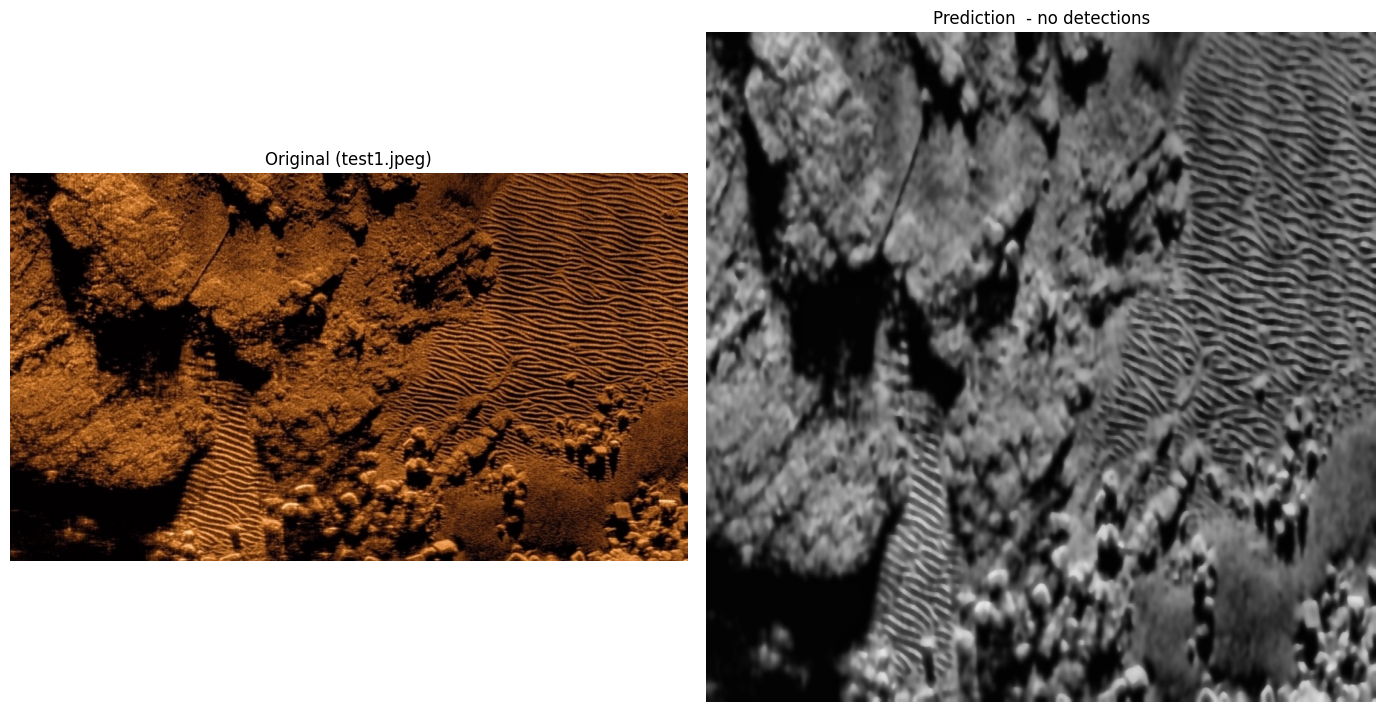

  test1.jpeg: 0 detection(s)  (no boxes drawn)


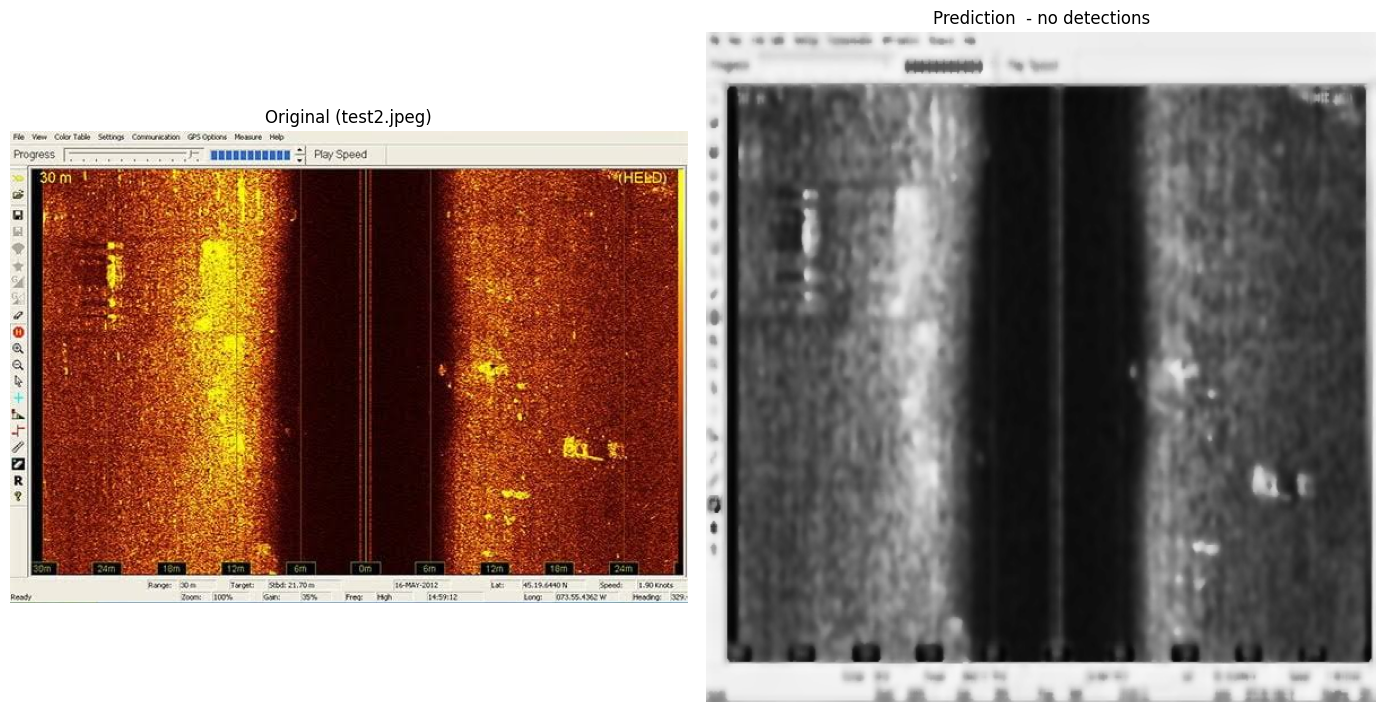

  test2.jpeg: 0 detection(s)  (no boxes drawn)


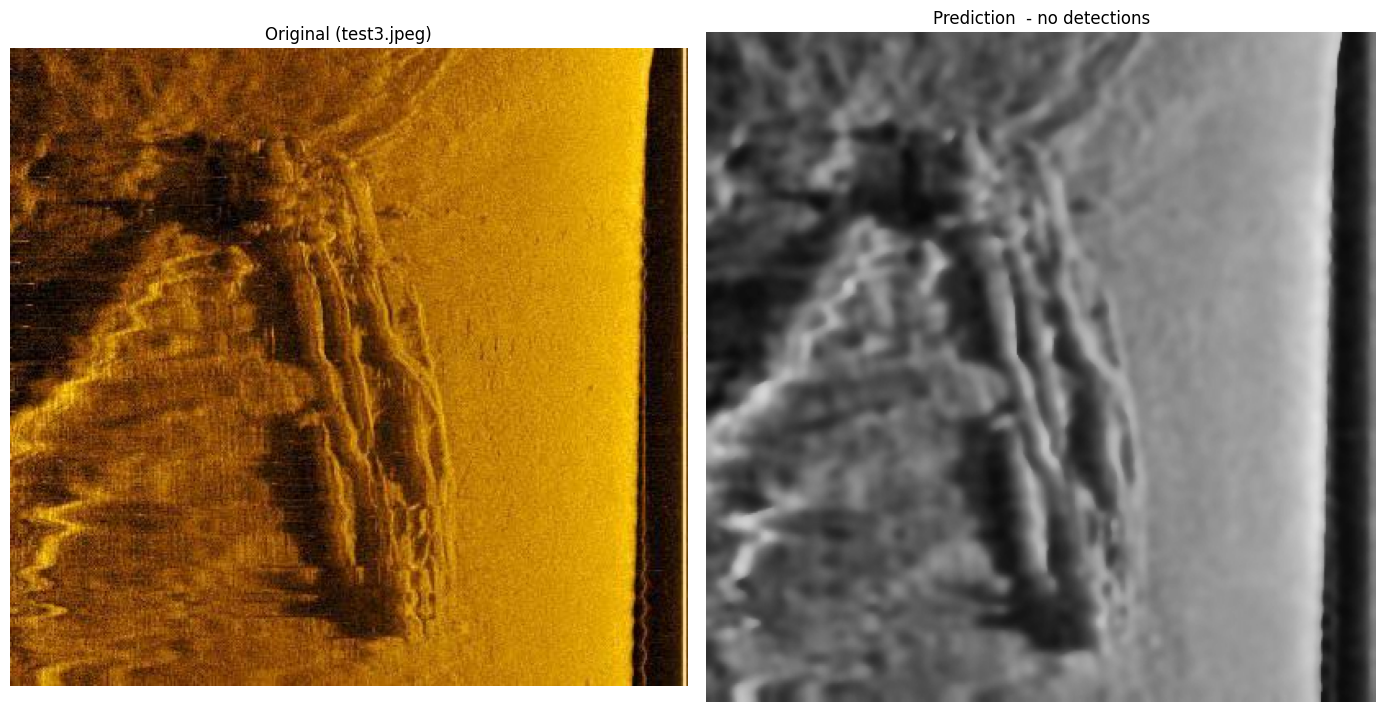

  test3.jpeg: 0 detection(s)  (no boxes drawn)


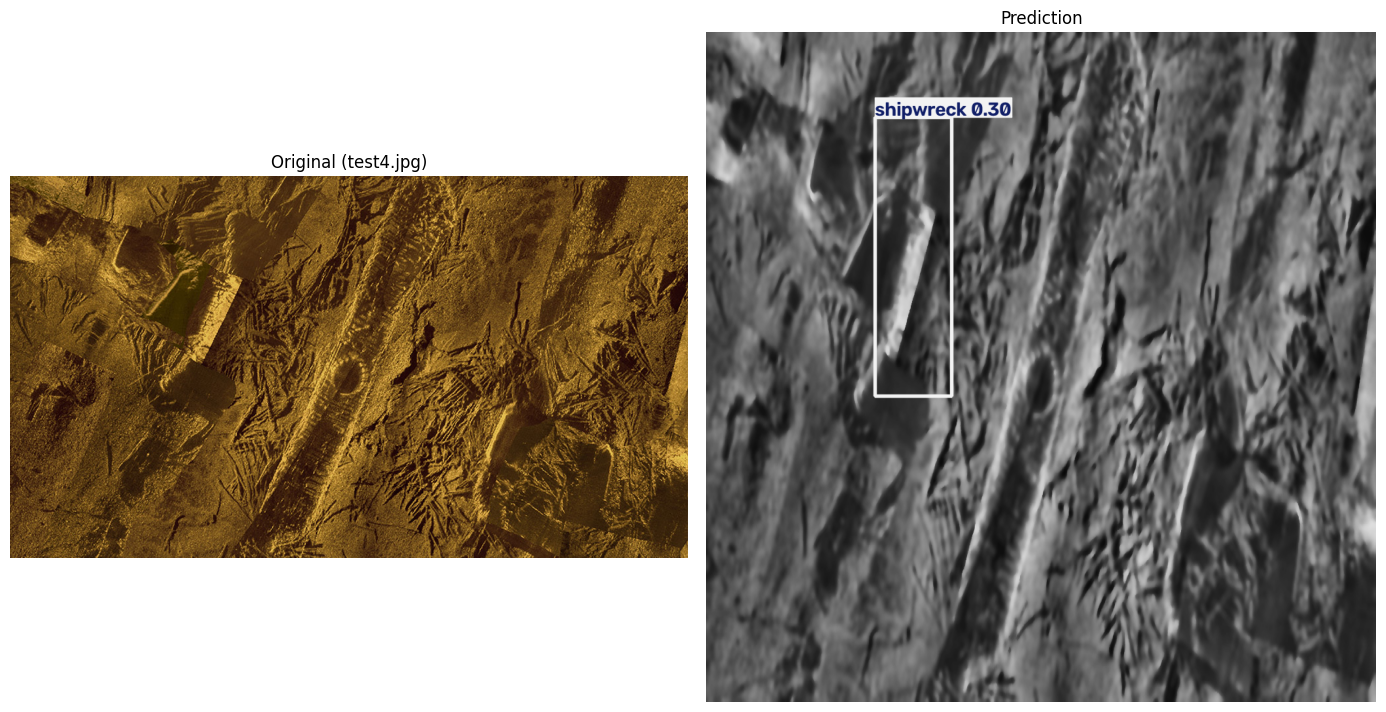

  test4.jpg: 1 detection(s)
     shipwreck conf=0.30


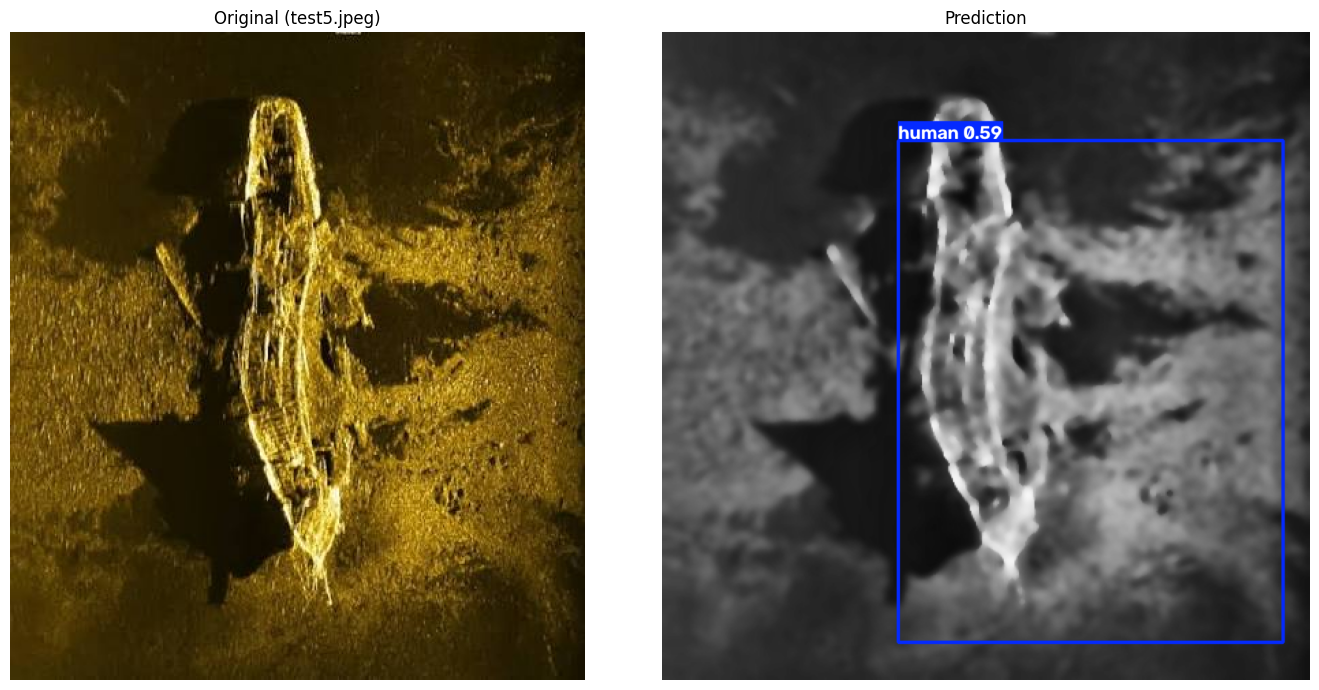

  test5.jpeg: 1 detection(s)
     human  conf=0.59


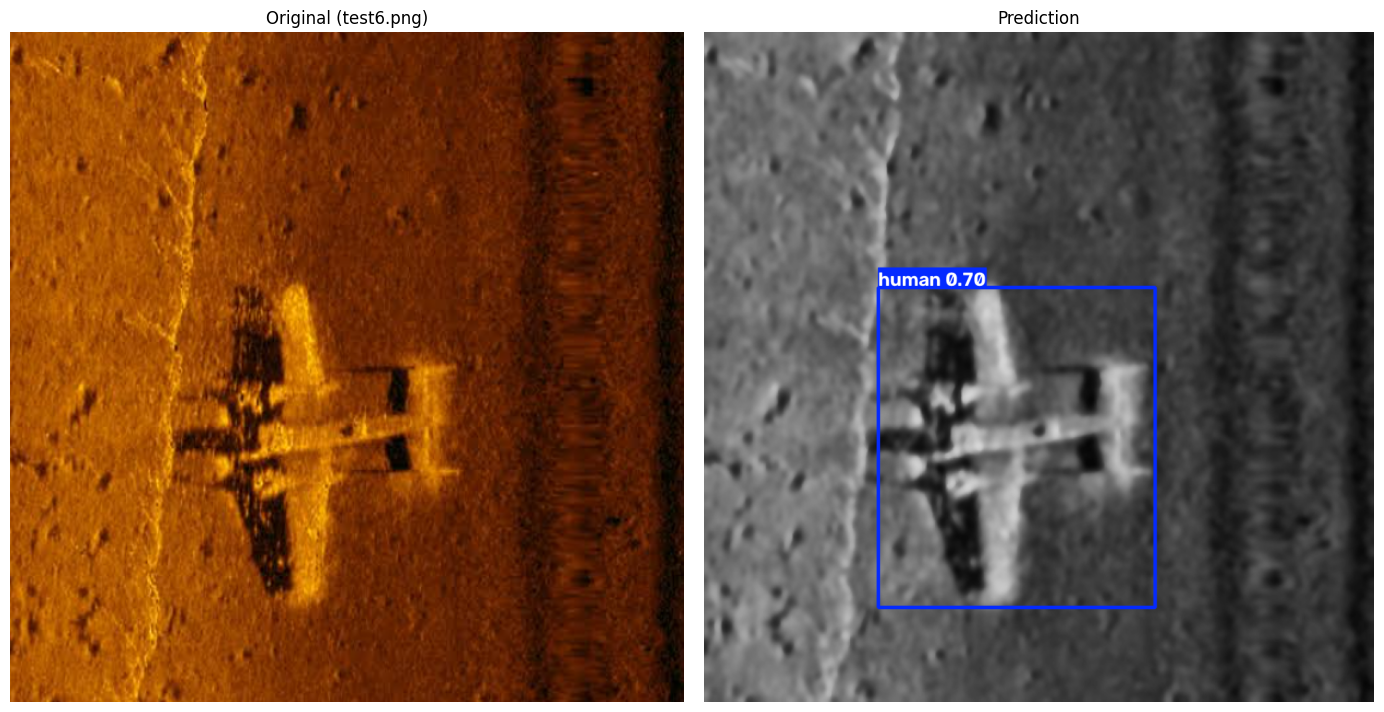

  test6.png: 1 detection(s)
     human  conf=0.70

=== SUMMARY ===
  test1.jpeg: 0 detection(s)
  test2.jpeg: 0 detection(s)
  test3.jpeg: 0 detection(s)
  test4.jpg: 1 detection(s)
  test5.jpeg: 1 detection(s)
  test6.png: 1 detection(s)


In [7]:
SOURCE_DIRS = [
    ROOT / "input" / "image",
]

results_summary = []

for src_dir in SOURCE_DIRS:
    if not src_dir.exists():
        print(f"!! skip (not found): {src_dir}")
        continue
    images = sorted(src_dir.glob("*"))
    print(f"\n=== {src_dir} ({len(images)} images) ===")

    for img_path in images:
        raw = cv2.imread(str(img_path))
        if raw is None:
            print("  !! cannot read:", img_path.name)
            continue

        # 1) noise filtering
        clean = preprocess(raw)

        # 2) prediction
        det = []
        if model is not None:
            result = model(clean, conf=CONF_THRESHOLD, verbose=False)[0]
            boxes = result.boxes
            if boxes is not None and len(boxes) > 0:
                for b in boxes:
                    det.append({
                        "cls": int(b.cls[0]),
                        "conf": float(b.conf[0]),
                        "xyxy": tuple(map(float, b.xyxy[0])),
                    })

        # 3) annotate image (only if detections found, else plain image)
        if det:
            annot = result.plot()
        else:
            annot = clean.copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor="white")
        axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original ({img_path.name})")
        axes[0].axis("off")
        axes[1].imshow(cv2.cvtColor(annot, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Prediction" + ("" if det else "  - no detections"))
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        n = len(det)
        print(f"  {img_path.name}: {n} detection(s)" + ("" if n else "  (no boxes drawn)"))
        for d in det:
            print(f"     {CLASS_NAMES.get(d['cls'], d['cls']):6s} conf={d['conf']:.2f}")
        results_summary.append({"image": img_path.name, "detections": n})

print("\n=== SUMMARY ===")
for r in results_summary:
    print(f"  {r['image']}: {r['detections']} detection(s)")

## 3. Save predictions

Saves annotated images (with boxes) to `output/predictions/image_prediction/`, and noise-filtered images to `output/noise_filter/input_noise_filter/images/`.

In [8]:
pred_out = ROOT / "output" / "predictions" / "image_prediction"
nf_out = ROOT / "output" / "noise_filter" / "input_noise_filter" / "images"
pred_out.mkdir(parents=True, exist_ok=True)
nf_out.mkdir(parents=True, exist_ok=True)

saved_pred, saved_nf = 0, 0
for src_dir in SOURCE_DIRS:
    if not src_dir.exists():
        continue
    for img_path in sorted(src_dir.glob("*")):
        raw = cv2.imread(str(img_path))
        if raw is None:
            continue
        clean = preprocess(raw)
        cv2.imwrite(str(nf_out / f"{img_path.stem}.png"), clean)
        saved_nf += 1
        annot = clean.copy()
        if model is not None:
            result = model(clean, conf=CONF_THRESHOLD, verbose=False)[0]
            boxes = result.boxes
            if boxes is not None and len(boxes) > 0:
                annot = result.plot()
        cv2.imwrite(str(pred_out / f"{img_path.stem}.png"), annot)
        saved_pred += 1

print(f"Saved {saved_nf} noise-filtered input images -> {nf_out}")
print(f"Saved {saved_pred} prediction images        -> {pred_out}")

Saved 6 noise-filtered input images -> D:\1. Project Program\1.SIH\SonarVision\output\noise_filter\input_noise_filter\images
Saved 6 prediction images        -> D:\1. Project Program\1.SIH\SonarVision\output\predictions\image_prediction
